# 7 · Transaction Costs and Turnover

*Common Core*

A strategy's backtest return is a *gross* return. What you keep is the *net* return, after paying to trade. This notebook adds trading costs to the backtest skeleton from notebook 4, and shows why some strategies survive costs and others don't.

## 1. Motivation

Some famous patterns in finance were real in the data and never profitable to trade. One example: stocks that fell most yesterday tended to bounce a little the next day. On paper, a strategy that buys yesterday's losers every day looked like a money machine. But it had to trade almost its whole portfolio every day, and a few basis points per trade wiped it out. Before any team presents a strategy, it should be able to answer: *how much can trading cost before this stops working?*

## 2. Intuition

Every time you change a position, you pay. From notebook 5, the bill has three parts: commissions, half the bid–ask spread, and price impact. For a liquid US stock and a small order, all three together are a few basis points.

That sounds negligible, but it is charged on **every trade**. What matters is how much you trade. That is measured by **turnover**: the fraction of the portfolio you buy or sell each period.

- A strategy that rebalances once a year might turn over 50% a year. At 5 bp per trade, it loses 0.025% a year to costs. Irrelevant.
- A strategy that replaces its whole portfolio every day turns over 200% a day (sell everything, buy everything new). At 5 bp, it loses 0.1% *per day*, or about 25% a year. Fatal.

So the key question is not "are my costs low?" but "**is my edge per trade bigger than my cost per trade?**"

## 3. The math

Let $w_{i,t}$ be the weight of asset $i$ held at the end of day $t$, and $R_{i,t}$ its return on day $t$.

**Gross return** (the weights chosen yesterday earn today's returns, as in notebook 4):
$$
R^{\text{gross}}_t = \sum_i w_{i,t-1}\, R_{i,t}.
$$

**Turnover** on day $t$: the total amount traded, as a fraction of capital:
$$
\text{TO}_t = \sum_i \big| w_{i,t} - w_{i,t-1} \big| .
$$
(To be exact, weights also drift with returns between rebalances. We ignore that small effect here.)

**Net return** with a cost of $c$ per unit traded (e.g. $c = 5\text{ bp} = 0.0005$):
$$
R^{\text{net}}_t = R^{\text{gross}}_t - c\,\text{TO}_t .
$$

**Break-even cost.** Average both sides over time. The strategy just breaks even when $\overline{R^{\text{gross}}} = c\,\overline{\text{TO}}$, so
$$
c^{*} = \frac{\overline{R^{\text{gross}}}}{\overline{\text{TO}}} .
$$
$c^*$ is the average profit per unit traded. If your real trading cost is above $c^*$, the strategy loses money. This one number summarises how robust a strategy is to costs.

## 4. Code it

### 4.1 Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.read_csv("../data/prices.csv", index_col="date", parse_dates=True)
meta = pd.read_csv("../data/meta.csv")

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 100, "axes.prop_cycle": plt.cycler(color=COLORS),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "lines.linewidth": 1.5, "font.size": 11,
})

stocks = meta.loc[meta.asset_type == "stock", "ticker"]
returns = prices[stocks].pct_change().dropna()

### 4.2 A backtest function with costs

This is the notebook 4 skeleton, generalised to many assets, with each formula from Section 3 on its own line.

In [2]:
def backtest(weights, returns, cost_bps=0.0):
    """Daily net returns and turnover for a DataFrame of target weights."""
    weights = weights.reindex(returns.index).fillna(0)
    gross = (weights.shift(1) * returns).sum(axis=1)       # sum_i w_{i,t-1} R_{i,t}
    turnover = weights.diff().abs().sum(axis=1)            # sum_i |w_{i,t} - w_{i,t-1}|
    net = gross - cost_bps / 1e4 * turnover                # R_gross - c * TO
    return net, gross, turnover

def sharpe(r):
    return np.sqrt(252) * r.mean() / r.std()

### 4.3 A famous anomaly that doesn't survive: short-term reversal

Each day, buy the stocks that fell most relative to the others yesterday, and short the ones that rose most. The weights are proportional to minus each stock's return relative to the average, scaled so that long plus short positions add up to 100% of capital. This is a **cross-sectional** strategy: it compares stocks with each other rather than predicting the market.

In [3]:
def normalise(w):
    """Scale each day's weights so that sum |w| = 1 (long + short = 100% of capital)."""
    return w.div(w.abs().sum(axis=1), axis=0)

demeaned = returns.sub(returns.mean(axis=1), axis=0)   # yesterday's return relative to the average stock
w_reversal = normalise(-demeaned)                       # minus: buy losers, sell winners

net, gross, turnover = backtest(w_reversal, returns)
print(f"Gross Sharpe ratio:     {sharpe(gross):.2f}")
print(f"Average daily turnover: {turnover.mean():.0%} of capital")
print(f"Break-even cost c*:     {gross.mean() / turnover.mean() * 1e4:.1f} bp")

Gross Sharpe ratio:     -0.13
Average daily turnover: 143% of capital
Break-even cost c*:     -0.3 bp


On large US stocks in 2010–2026, short-term reversal has **no edge even before costs**: the gross Sharpe ratio is slightly negative. Meanwhile it trades about 143% of capital *every day*. Even if the old edge still existed, a typical edge for this strategy was a few basis points per unit traded, about what it costs to trade. Patterns like this get traded away by high-frequency firms whose costs are a fraction of a basis point. For everyone else they are out of reach.

### 4.4 A signal with a real edge: 12-month momentum

**Momentum** is the opposite idea, on a much longer horizon: stocks that did best over the past year tend to keep outperforming for a while. The usual signal is the return from 12 months ago to 1 month ago (skipping the most recent month, which tends to reverse). Notebook SR1 covers it in detail. Here we use it to study costs. First we recompute the target weights every day.

In [4]:
mom = prices[stocks].shift(21) / prices[stocks].shift(252) - 1     # return from t-252 to t-21
w_mom_daily = normalise(mom.sub(mom.mean(axis=1), axis=0)).reindex(returns.index)

def summary(name, w):
    _, g, to = backtest(w, returns)
    g, to = g["2011":], to["2011":]                    # skip the first year (signal warming up)
    print(f"{name:<28} gross Sharpe {sharpe(g):.2f} | turnover {to.mean():5.1%}/day | "
          f"break-even c* {g.mean() / to.mean() * 1e4:5.1f} bp")

summary("Momentum, daily rebalance", w_mom_daily)

Momentum, daily rebalance    gross Sharpe 0.57 | turnover  8.5%/day | break-even c*  28.8 bp


Momentum has a positive gross Sharpe ratio of about 0.57 (flattered by survivorship, notebook 6). It also trades far less: about 8.5% of capital per day, against 143% for reversal. Its break-even cost is about 29 bp, roughly ten times what a liquid large-cap stock costs to trade. That leaves a real margin of safety.

### 4.5 Trading less: rebalance monthly

The momentum signal changes slowly, so recomputing it every day mostly adds small, noisy trades. Here we only rebalance on the last trading day of each month and hold the weights in between.

Momentum, daily rebalance    gross Sharpe 0.57 | turnover  8.5%/day | break-even c*  28.8 bp
Momentum, monthly rebalance  gross Sharpe 0.44 | turnover  1.9%/day | break-even c*  98.6 bp


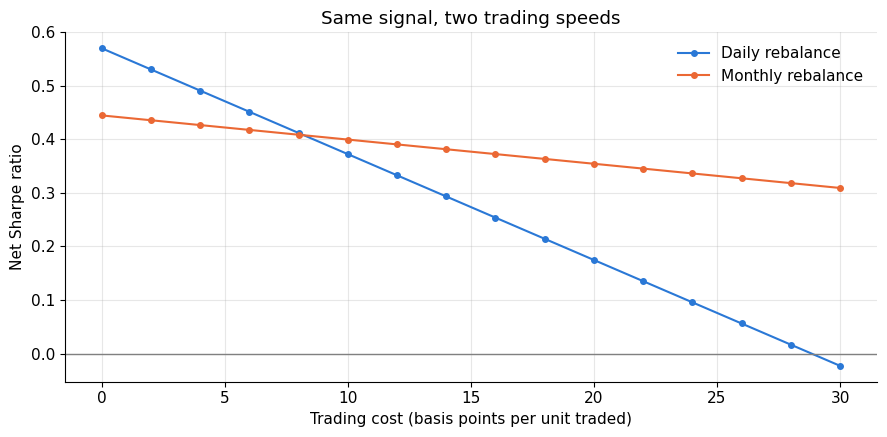

In [5]:
dates = w_mom_daily.index.to_series()
month_end = dates.groupby(dates.dt.to_period("M")).transform("max") == dates   # last day of each month
w_mom_monthly = w_mom_daily.where(month_end, axis=0).ffill()                     # hold between rebalances

summary("Momentum, daily rebalance", w_mom_daily)
summary("Momentum, monthly rebalance", w_mom_monthly)

costs = np.arange(0, 31, 2)    # 0 to 30 basis points per unit traded
fig, ax = plt.subplots()
for name, w in [("Daily rebalance", w_mom_daily), ("Monthly rebalance", w_mom_monthly)]:
    net_sharpes = [sharpe(backtest(w, returns, c)[0]["2011":]) for c in costs]
    ax.plot(costs, net_sharpes, marker="o", markersize=4, label=name)
ax.axhline(0, color="grey", linewidth=1)
ax.set_xlabel("Trading cost (basis points per unit traded)")
ax.set_ylabel("Net Sharpe ratio")
ax.set_title("Same signal, two trading speeds")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Rebalancing monthly gives up some gross performance: the Sharpe ratio drops from 0.57 to 0.44, because the weights are up to a month stale. But turnover falls by more than 75%, and the break-even cost rises from about 29 bp to about 99 bp. The plot shows the trade-off. At zero cost, daily rebalancing wins. Above about 8 bp, monthly rebalancing wins. At 30 bp, the daily version has lost its whole edge, while the monthly version still has a Sharpe ratio above 0.3. With realistic costs, **trading less often is often the best improvement you can make**.

## 5. Takeaways and where it breaks

- **Always report net returns** and the cost assumption used. A gross Sharpe ratio on its own says little.
- **Turnover is the lever.** The same signal traded more slowly can survive costs that kill the fast version, but only if the signal itself lasts long enough.
- **Break-even cost $c^*$** is the single number that tells you whether a strategy can be traded. Compare it with the cost estimates from notebook 5.
- **Where it breaks:** a flat cost per unit traded ignores impact growing with size (square-root law), different costs for different stocks, and the extra cost of short selling (borrow fees).
- **Ignored here:** weight drift between rebalances, and the fact that cost-aware optimisation (trading only partly towards the target) usually beats simple fixed schedules.

**What you could build:** a cost-and-capacity report for any strategy: break-even cost, net Sharpe at realistic costs, and the largest fund size before square-root impact eats the edge.